In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Exploratory Data Analysis

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the ABT
df = pd.read_csv('../data/NYC_Taxi_ABT.csv')

Net Revenue per Hour Quantiles:
0.010     $31.13
0.050     $59.18
0.250     $77.37
0.500     $92.96
0.750    $115.66
0.900    $148.04
0.950    $175.21
0.990    $252.89
0.999    $537.35
Name: net_revenue_per_hour, dtype: str

99th percentile cap for readable plotting: $252.89


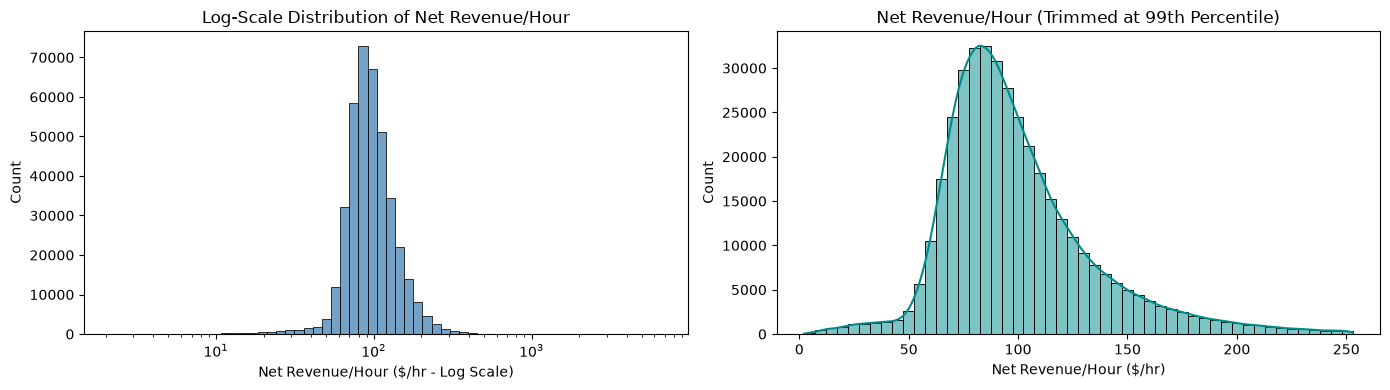

In [4]:
# Sample 10% for fast visualization
eda_df = df.sample(frac=0.10, random_state=42).copy()

# Inspect distribution quantiles for net_revenue_per_hour
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
print("Net Revenue per Hour Quantiles:")
print(eda_df['net_revenue_per_hour'].quantile(quantiles).apply(lambda x: f"${x:,.2f}"))

# Identify upper threshold for plotting to handle extreme trip outliers
cap_value = eda_df['net_revenue_per_hour'].quantile(0.99)
print(f"\n99th percentile cap for readable plotting: ${cap_value:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
sns.histplot(eda_df['net_revenue_per_hour'], bins=60, log_scale=True, ax=axes[0], color='steelblue')
axes[0].set_title('Log-Scale Distribution of Net Revenue/Hour')
axes[0].set_xlabel('Net Revenue/Hour ($/hr - Log Scale)')

# Filtered distribution
sns.histplot(eda_df[eda_df['net_revenue_per_hour'] <= cap_value]['net_revenue_per_hour'], 
             bins=50, kde=True, ax=axes[1], color='darkcyan')
axes[1].set_title('Net Revenue/Hour (Trimmed at 99th Percentile)')
axes[1].set_xlabel('Net Revenue/Hour ($/hr)')

plt.tight_layout()
plt.show()

C:\Users\Fernand\AppData\Local\Temp\ipykernel_34088\1893158045.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_agg, x='day_of_week', y='net_revenue_per_hour', palette='Blues_d', ax=axes[1])


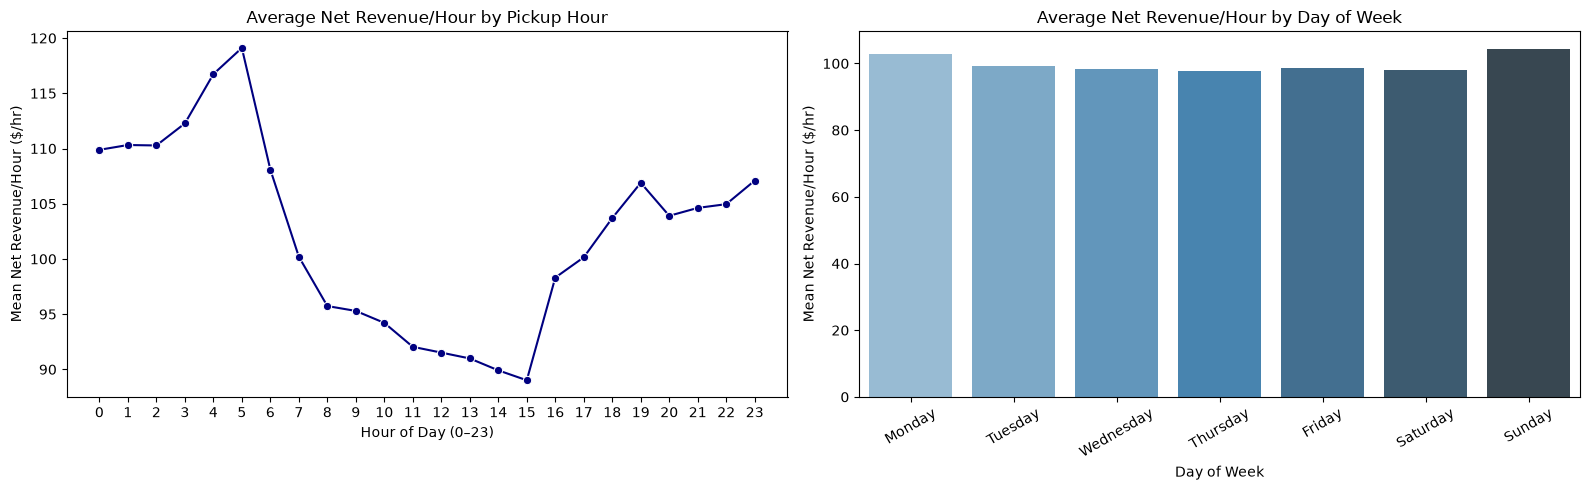

In [5]:
# Trimmed dataframe for clear charts
viz_df = eda_df[eda_df['net_revenue_per_hour'] <= cap_value]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Hourly trends
hourly_agg = viz_df.groupby('pickup_hour')['net_revenue_per_hour'].mean().reset_index()
sns.lineplot(data=hourly_agg, x='pickup_hour', y='net_revenue_per_hour', marker='o', ax=axes[0], color='navy')
axes[0].set_title('Average Net Revenue/Hour by Pickup Hour')
axes[0].set_xlabel('Hour of Day (0–23)')
axes[0].set_ylabel('Mean Net Revenue/Hour ($/hr)')
axes[0].set_xticks(range(0, 24))

# 2. Day of Week trends
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_agg = viz_df.groupby('day_of_week')['net_revenue_per_hour'].mean().reindex(weekday_order).reset_index()
sns.barplot(data=day_agg, x='day_of_week', y='net_revenue_per_hour', palette='Blues_d', ax=axes[1])
axes[1].set_title('Average Net Revenue/Hour by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Net Revenue/Hour ($/hr)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

C:\Users\Fernand\AppData\Local\Temp\ipykernel_34088\3297151250.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='mean_revenue', y=top_10['PULocationID'].astype(str),
C:\Users\Fernand\AppData\Local\Temp\ipykernel_34088\3297151250.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x='mean_revenue', y=bottom_10['PULocationID'].astype(str),


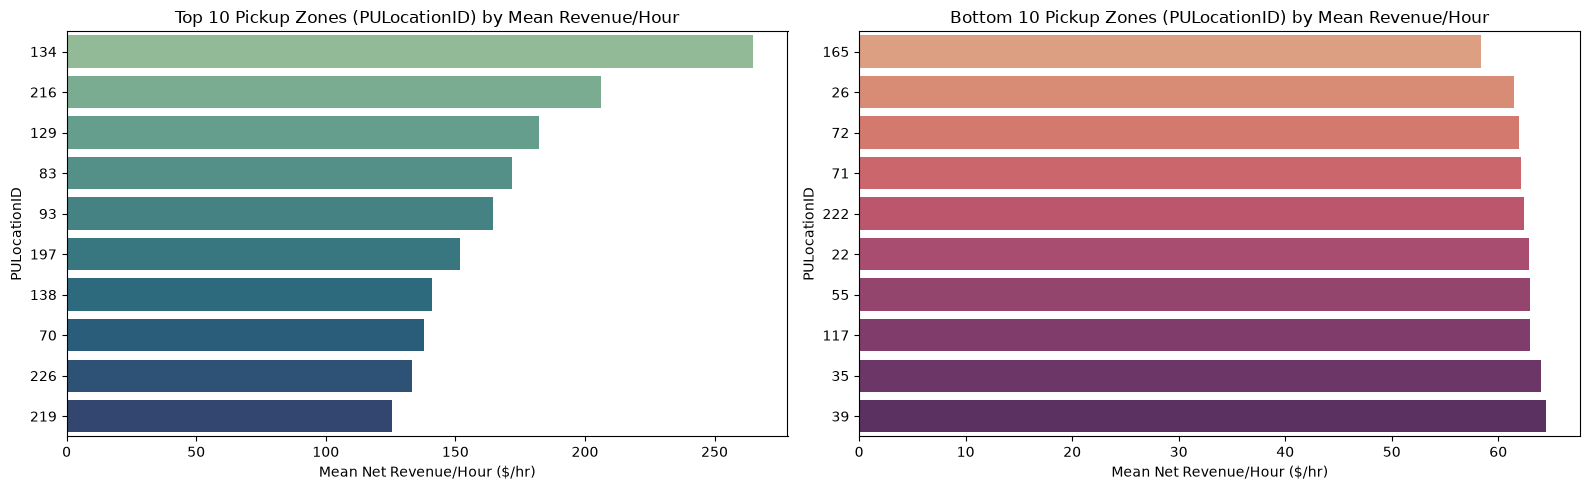

In [6]:
# Compute mean revenue and trip volume per zone
zone_stats = eda_df.groupby('PULocationID').agg(
    mean_revenue=('net_revenue_per_hour', 'mean'),
    trip_count=('net_revenue_per_hour', 'count')
).reset_index()

# Keep zones with sufficient support
zone_stats_filtered = zone_stats[zone_stats['trip_count'] >= 50]

top_10 = zone_stats_filtered.nlargest(10, 'mean_revenue')
bottom_10 = zone_stats_filtered.nsmallest(10, 'mean_revenue')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top_10, x='mean_revenue', y=top_10['PULocationID'].astype(str), 
            palette='crest', ax=axes[0])
axes[0].set_title('Top 10 Pickup Zones (PULocationID) by Mean Revenue/Hour')
axes[0].set_xlabel('Mean Net Revenue/Hour ($/hr)')
axes[0].set_ylabel('PULocationID')

sns.barplot(data=bottom_10, x='mean_revenue', y=bottom_10['PULocationID'].astype(str), 
            palette='flare', ax=axes[1])
axes[1].set_title('Bottom 10 Pickup Zones (PULocationID) by Mean Revenue/Hour')
axes[1].set_xlabel('Mean Net Revenue/Hour ($/hr)')
axes[1].set_ylabel('PULocationID')

plt.tight_layout()
plt.show()

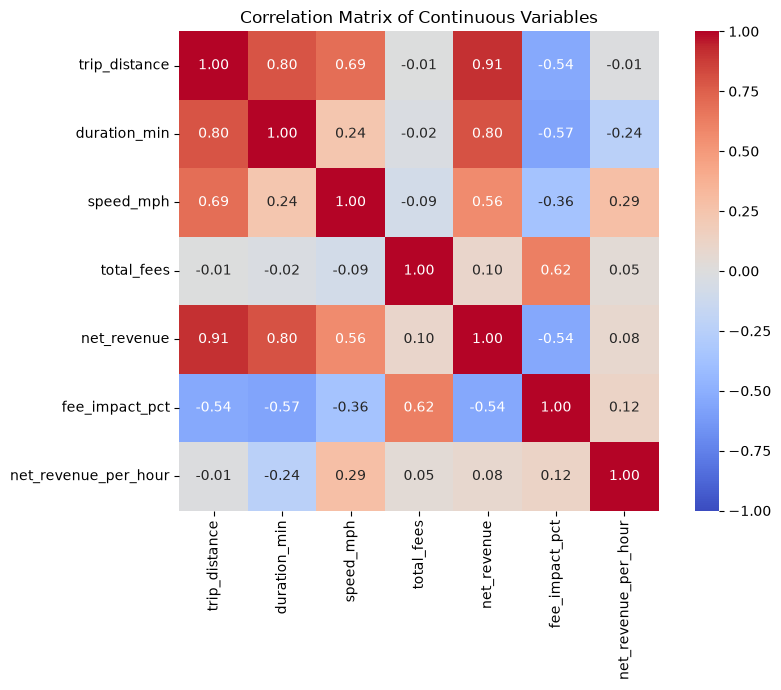

In [7]:
# Numerical variables
num_cols = [
    'trip_distance', 'duration_min', 'speed_mph', 
    'total_fees', 'net_revenue', 'fee_impact_pct', 
    'net_revenue_per_hour'
]

corr_matrix = eda_df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Continuous Variables')
plt.tight_layout()
plt.show()

# Data Cleaning

In [8]:
initial_rows = len(df)

# 1. Remove negative fees, taxes, and fare adjustments
fee_cols = [
    'cbd_congestion_fee', 'congestion_surcharge', 'Airport_fee', 
    'mta_tax', 'extra', 'improvement_surcharge', 'tolls_amount', 
    'tip_amount', 'total_fees', 'fee_impact_pct'
]
df = df[(df[fee_cols] >= 0).all(axis=1)].copy()
after_fees = len(df)
print(f"Rows after removing negative fees/taxes: {after_fees:,} (Dropped {initial_rows - after_fees:,})")

# 2. Ensure strictly positive fare and net revenue amounts
df = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0) & (df['net_revenue'] > 0)].copy()
after_revenue = len(df)
print(f"Rows after enforcing positive revenue:   {after_revenue:,} (Dropped {after_fees - after_revenue:,})")

# 3. Remove zero-passenger trips and invalid TLC RatecodeIDs (valid codes are 1 to 6)
df = df[(df['passenger_count'] > 0) & (df['RatecodeID'].between(1, 6))].copy()
after_validity = len(df)
print(f"Rows after removing invalid trips/codes: {after_validity:,} (Dropped {after_revenue - after_validity:,})")

# 4. Filter extreme target outliers (capping net_revenue_per_hour at $500/hr)
df = df[df['net_revenue_per_hour'] <= 500].copy()
final_rows = len(df)
print(f"Rows after capping target outliers:      {final_rows:,} (Dropped {after_validity - final_rows:,})")

print(f"\nTotal rows removed: {initial_rows - final_rows:,} ({((initial_rows - final_rows) / initial_rows) * 100:.2f}%)")

Rows after removing negative fees/taxes: 3,946,620 (Dropped 75)
Rows after enforcing positive revenue:   3,946,620 (Dropped 0)
Rows after removing invalid trips/codes: 3,857,221 (Dropped 89,399)
Rows after capping target outliers:      3,852,830 (Dropped 4,391)

Total rows removed: 93,865 (2.38%)


In [9]:
print("----- FINAL CHECK -----")
print(f"Final Row Count:       {len(df):,}")
print(f"Total Missing Values:  {df.isnull().sum().sum()}")
print(f"Min Total Fees:        ${df['total_fees'].min():.2f}")
print(f"Min Fee Impact %:      {df['fee_impact_pct'].min():.2f}%")
print(f"Min Passenger Count:   {df['passenger_count'].min()}")
print(f"Max RatecodeID:        {df['RatecodeID'].max()}")
print(f"Min Speed (mph):       {df['speed_mph'].min():.2f}")
print(f"Max Net Revenue/Hour:  ${df['net_revenue_per_hour'].max():.2f}/hr")

----- FINAL CHECK -----
Final Row Count:       3,852,830
Total Missing Values:  0
Min Total Fees:        $0.00
Min Fee Impact %:      0.00%
Min Passenger Count:   1
Max RatecodeID:        6
Min Speed (mph):       1.00
Max Net Revenue/Hour:  $500.00/hr


In [10]:
output_path = '../data/Final_NYC_Taxi_Cleaned.csv'
df.to_csv(output_path, index=False)